In [48]:
# Import your existing types and functions
from typing import Optional, Union
from dataclasses import dataclass
import random
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch

import pandas as pd
import torch
from torch import Tensor
from jaxtyping import Float, Int, Bool

from js_embedding_vis import write_inlined_config

from muutils.collect_warnings import CollateWarnings
from muutils.dbg import dbg_auto, dbg_tensor
import matplotlib.pyplot as plt


from spd.analysis.embed_vis import AnalysisConfig, coactivation_analysis, plot_embedding_label_grid
from spd.analysis.grouping import (
    CoactivationResults,
    CoactivationResultsGroup,
    get_coactivations,
)
from spd.data_utils import SparseFeatureDataset
from spd.experiments.resid_mlp.resid_mlp_dataset import ResidualMLPDataset
from spd.utils import get_device_torch

In [30]:
# magic autoreload
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [49]:
DEVICE = get_device_torch()
torch.set_grad_enabled(False)
print(f"Using device: {DEVICE = }")

Using device: DEVICE = device(type='cuda')


In [52]:
COACTIVATIONS = get_coactivations(
    model_path=Path("../data/mlp-decomp/model_30000.pth"),
    dataset_cls=ResidualMLPDataset,
    dataset_kwargs=dict(
        calc_labels=False,  # Our labels will be the output of the target model
        label_type=None,
        act_fn_name=None,
        label_fn_seed=None,
        label_coeffs=None,
        synced_inputs=None,
    ),
	dataloader_kwargs=dict(
		batch_size=10000,
    ),
    coactivations_kwargs=dict(
        module_groups=[["layers.0.mlp_in", "layers.0.mlp_out"]],
		n_samples=10000,
    ),
    device=DEVICE,
)["group_0"]



dbg_auto(COACTIVATIONS);

[ <ipykernel>:24 ] COACTIVATIONS: <dict of len()=12, key_types={str}, val_types={Tensor, dict, float, int, list, ndarray}>
  co_occurrence_matrix: μ=50.07 σ=167.62 x̃=0.00 R=[0.00,2048.00] ℙ˪=|█▅▆ ▁▂▃| shape=(200,200) dtype=torch.float32 device=cuda:0 ∇✗
  marginal_counts: μ=502.58 σ=766.02 x̃=92.00 R=[0.00,2048.00] ℙ=|█     ▂| shape=200 dtype=torch.float32 device=cuda:0 ∇✗
  module_slices:   <dict of len()=2, key_types={str}, val_types={slice}>
    layers.0.mlp_in: slice(0, 100, None)
    layers.0.mlp_out: slice(100, 200, None)
  modules: ['layers.0.mlp_in', 'layers.0.mlp_out']
  labels: shape=200 dtype=<U16
  component_masks: μ=0.02 σ=0.14 x̃=-0.00 R=[-0.05,1.00] ℙ˪=|█▆▅▅▅▅▆| shape=(10000,200) dtype=torch.float32 device=cuda:0 ∇✗
  active_mask: μ=0.05 σ=0.22 x̃=0.00 R=[0,1] ℙ˪=|█     ▆| shape=(10000,200) dtype=torch.bool device=cuda:0 ∇✗
  active_freq: μ=0.05 σ=0.08 x̃=0.01 R=[0.00,0.20] ℙ=|█     ▂| shape=200 dtype=torch.float32 device=cuda:0 ∇✗
  is_alive: μ=0.75 σ=0.43 x̃=1.00 R=[0

the above actually makes sense. the last 100 are the superimposed components which we expect to merge into one super-component.	

/home/miv/projects/MATS/apd/.venv/lib/python3.11/site-packages/muutils/tensor_info.py:260: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  hist, bins = np.histogram(A_hist, bins=hist_bins)
[ <ipykernel>:32 -> compute_merge_costs ] activation_mask: μ=0.05 σ=0.22 x̃=0.00 R=[0,1] ℙ˪=|█     ▆| shape=(10000,200) dtype=torch.bool device=cuda:0 ∇✗
[ <ipykernel>:33 -> compute_merge_costs ] merge_matrices: μ=0.01 σ=0.07 x̃=0.00 R=[0,1] ℙ˪=|█     ▄| shape=(1,200,200) dtype=torch.bool device=cpu ∇✗
[ <ipykernel>:35 -> compute_merge_costs ] x: μ=0.01 σ=0.09 x̃=0.00 R=[0,1] ℙ˪=|█     ▄| shape=(10000,1) dtype=torch.bool device=cuda:0 ∇✗


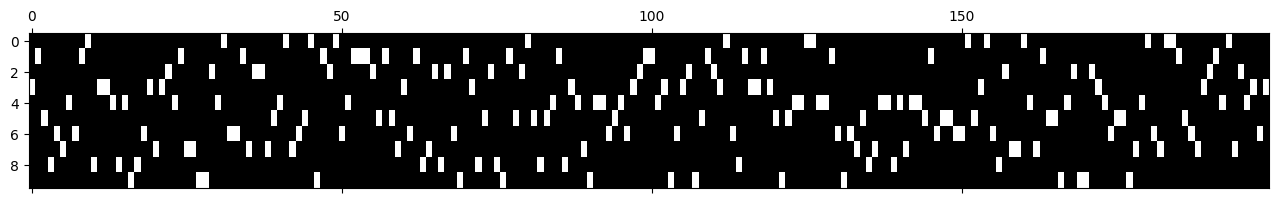

In [53]:
def compute_merge_costs(
    activation_mask: Bool[Tensor, "n_samples n_components"],
    merge_matrices: Bool[Tensor, "*batch_size k_groups n_components"],
    alpha: float = 1.0,
) -> Float[Tensor, "*batch_size"]:
    """Compute MDL costs for merge matrices (supports single matrix or batches)"""
    # Handle single matrix case by adding batch dimension
    squeeze_output: bool = False
    if merge_matrices.ndim == 2:
        merge_matrices = merge_matrices.unsqueeze(0)
        squeeze_output = True
    
    # batch_shape: tuple[int, int] = tuple(merge_matrices.shape[:-2]) # type: ignore
    batch_size: int = merge_matrices.shape[0]
    k_groups: int = merge_matrices.shape[-2]
    n_components: int = merge_matrices.shape[-1]
    device: torch.device = activation_mask.device
    
    # Group ranks: [batch_size, k]
    group_ranks: Int[Tensor, "batch_size k_groups"] = merge_matrices.sum(dim=2).int()
    component_sums: Int[Tensor, "batch_size n_components"] = merge_matrices.sum(dim=1).int()
    assert group_ranks.shape == (batch_size, k_groups), f"Expected group_ranks shape {(batch_size, k_groups)}, got {group_ranks.shape}"
    assert component_sums.shape == (batch_size, n_components), f"Expected component_sums shape {(batch_size, n_components)}, got {component_sums.shape}"
    assert component_sums.eq(1).all(), "Expected one-hot in each component"
    
    # Group marginal counts via max pooling: [batch_size, k_groups]
    group_activation_prob: Float[Tensor, "batch_size k_groups"] = torch.full((batch_size, k_groups), torch.nan, device=device)
    # each group is `True` for indices of components it contains
    # the group is active if *any* component in it is active, we want a count across all samples
    # so, for each each group in each batch element, select the components in that group from the activation mask
    # take the max with respect to each samples, and them take the mean across all samples
    dbg_tensor(activation_mask)
    dbg_tensor(merge_matrices)
    x = activation_mask[:, merge_matrices[0,0]]
    dbg_tensor(x)
    
    
    # # Group co-occurrence via max pooling: [batch_size, k, k]
    # group_co_occurrence = torch.zeros(batch_size, k_groups, k_groups, device=device)
    # for b in range(batch_size):
    #     for i in range(k_groups):
    #         for j in range(k_groups):
    #             if merge_matrices[b, i].any() and merge_matrices[b, j].any():
    #                 submatrix = co_occurrence_matrix[merge_matrices[b, i]][:, merge_matrices[b, j]]
    #                 group_co_occurrence[b, i, j] = submatrix.max()
    
    # # Vectorized cost computation: [batch_size, k, k]
    # cost_terms = (
    #     alpha * group_marginal_counts.unsqueeze(2) * group_ranks.unsqueeze(1) +  # [batch_size, k, k]
    #     alpha * group_marginal_counts.unsqueeze(1) * group_ranks.unsqueeze(2) -  # [batch_size, k, k]
    #     group_co_occurrence * (alpha * group_ranks.unsqueeze(2) + alpha * group_ranks.unsqueeze(1) + 1)  # [batch_size, k, k]
    # )
    
    # # Sum over all pairs: [batch_size]
    # total_costs = cost_terms.sum(dim=(1, 2))
    
    # # Reshape back to original batch shape
    # total_costs = total_costs.view(batch_shape)
    
    # # Squeeze if input was single matrix
    # if squeeze_output:
    #     total_costs = total_costs.squeeze()
    
    # return total_costs

def rand_merge_mat(
    n_components: int,
    k_groups: int,
    device: torch.device = DEVICE,
) -> Bool[Tensor, "k_groups n_components"]:
    """Generate a random merge matrix with given number of components and groups."""
    group_idxs: Int[Tensor, "n_components"] = torch.randint(
        low=0,
        high=k_groups,
        size=(n_components,),
        device=DEVICE,
    )
    merge_matrix: Bool[Tensor, "k_groups n_components"] = torch.zeros(
        size=(k_groups, n_components),
        dtype=torch.bool,
        device=device,
    )
    merge_matrix[group_idxs, torch.arange(n_components, device=device)] = True
    return merge_matrix

mm = rand_merge_mat(
    n_components=200,
    k_groups=10,
)

plt.matshow(mm.cpu().numpy(), cmap='gray', aspect='auto')

compute_merge_costs(
    activation_mask=COACTIVATIONS['active_mask'],
    merge_matrices=torch.eye(200).bool(),
    alpha=1.0,
)

In [ ]:


def generate_all_merge_matrices(n_components: int, k: int, device=None) -> Bool[Tensor, "n_matrices k n_components"]:
    """Generate all possible merge matrices as single tensor"""
    if device is None:
        device = torch.device('cpu')
    
    # Total possibilities: k^n_components
    n_total = k ** n_components
    
    # Generate all base-k assignments
    assignments = torch.zeros(n_total, n_components, dtype=torch.long, device=device)
    
    for i in range(n_total):
        temp = i
        for j in range(n_components):
            assignments[i, j] = temp % k
            temp //= k
    
    # Convert to one-hot merge matrices
    merge_matrices = torch.zeros(n_total, k, n_components, dtype=torch.bool, device=device)
    batch_indices = torch.arange(n_total, device=device).unsqueeze(1)  # [n_total, 1]
    component_indices = torch.arange(n_components, device=device).unsqueeze(0)  # [1, n_components]
    
    merge_matrices[batch_indices, assignments, component_indices] = True
    
    # Filter out matrices with empty groups
    group_counts = merge_matrices.sum(dim=2)  # [n_total, k]
    valid_mask = (group_counts > 0).all(dim=1)  # [n_total]
    
    return merge_matrices[valid_mask]


def find_all_merge_costs(
    co_occurrence_matrix: Float[Tensor, "n_components n_components"],
    marginal_counts: Float[Tensor, "n_components"],
    k: int,
    alpha: float = 1.0,
) -> Float[Tensor, "n_matrices"]:
    """Return costs for all possible merge matrices"""
    all_matrices = generate_all_merge_matrices(marginal_counts.shape[0], k, marginal_counts.device)
    return compute_merge_costs(co_occurrence_matrix, marginal_counts, all_matrices, alpha)


def greedy_merge_search(
    co_occurrence_matrix: Float[Tensor, "n_components n_components"],
    marginal_counts: Float[Tensor, "n_components"],
    k: int,
    alpha: float = 1.0,
    temperature: float = 0.0,
    seed: Optional[int] = None,
) -> tuple[Bool[Tensor, "k n_components"], float]:
    """Greedy search with optional temperature sampling"""
    if seed is not None:
        torch.manual_seed(seed)
    
    n_components = marginal_counts.shape[0]
    device = marginal_counts.device
    
    # Start with identity
    merge_matrix = torch.eye(n_components, dtype=torch.bool, device=device)
    current_k = n_components
    
    while current_k > k:
        # Generate all possible merge candidates
        candidates = []
        
        for i in range(current_k):
            for j in range(i + 1, current_k):
                # Create candidate by merging groups i and j
                candidate = merge_matrix.clone()
                candidate[i] = candidate[i] | candidate[j]
                
                # Remove group j by shifting
                if j < current_k - 1:
                    candidate[j:current_k-1] = candidate[j+1:current_k]
                candidate = candidate[:current_k-1]
                
                candidates.append(candidate)
        
        # Compute costs for all candidates
        if len(candidates) > 0:
            candidate_stack = torch.stack(candidates)  # [n_candidates, current_k-1, n_components]
            
            # Compute current cost
            current_cost = compute_merge_costs(co_occurrence_matrix, marginal_counts, merge_matrix, alpha)
            
            # Compute candidate costs
            candidate_costs = compute_merge_costs(co_occurrence_matrix, marginal_counts, candidate_stack, alpha)
            cost_deltas = candidate_costs - current_cost
            
            # Select based on temperature
            if temperature == 0.0:
                best_idx = cost_deltas.argmin().item()
            else:
                probs = torch.softmax(-cost_deltas / temperature, dim=0)
                best_idx = torch.multinomial(probs, 1).item()
            
            merge_matrix = candidates[best_idx]
            current_k -= 1
        else:
            break
    
    final_cost = compute_merge_costs(co_occurrence_matrix, marginal_counts, merge_matrix, alpha)
    return merge_matrix, final_cost